# CO2 Emmissions by cars 


## **Project Definition and Goal**<br> 



### Identifying the car technical characteristics that play a role in pollution 

<span style="font-size: 18px">

- This project aims to identify which technical characteristics<br>
of newly registered vehicles most influence their CO₂ emissions.<br>
Our goal is to uncover patterns and predictors of emissions<br>
performance that can inform sustainable vehicle design, <br>
manufacturing strategies, and environmental policy<br>

<br>
    To develop a robust and well-tested approach, we begin<br>
with a focused exploratory analysis using a 2013 dataset<br>
of cars sold in France. Once the analytical pipeline<br>
is validated on this smaller, simpler dataset,<br>
we will apply the same methodology to the<br>
full-scale European Environment Agency (EEA) 2023<br> dataset.
This ensures both efficiency in development and <br>
relevance in our final insights.<br>

## **Datasets Overview**



We'll begin our study with two datasets:

### 1. **France 2013 dataset** (initial EDA phase)

- Contains technical and environmental specifications of passenger cars sold in France in 2013  
- Includes CO₂ emissions, fuel consumption, engine power, mass, and fuel type  
- Used to prototype visualizations, hypothesis tests, and feature selection  

### 2. **EEA 2023 dataset** (main analysis phase)

- Covers all new passenger cars registered in the European Union in 2023  
- Includes updated WLTP-based CO₂ measurements and richer technical data  
- Used to produce the final results and insights relevant to current EU mobility trends  

### Column Descriptions — 2023 EEA


| Name          | Definition                                                                                                |
| ------------- | --------------------------------------------------------------------------------------------------------- |
| ID            | Identification number.                                                                                    |
| MS            | Member state.                                                                                             |
| Mp            | Manufacturer pooling.                                                                                     |
| VFN           | Vehicle family identification number.                                                                     |
| Mh            | Manufacturer name EU standard denomination .                                                              |
| Man           | Manufacturer name OEM declaration.                                                                        |
| MMS           | Manufacturer name MS registry denomination .                                                              |
| TAN           | Type approval number.                                                                                     |
| T             | Type.                                                                                                     |
| Va            | Variant.                                                                                                  |
| Ve            | Version.                                                                                                  |
| Mk            | Make.                                                                                                     |
| Cn            | Commercial name.                                                                                          |
| Ct            | Category of the vehicle type approved.                                                                    |
| Cr            | Category of the vehicle registered.                                                                       |
| M (kg)        | Mass in running order Completed/complete vehicle .                                                        |
| Mt            | WLTP test mass.                                                                                           |
| Enedc (g/km)  | Specific CO2 Emissions (NEDC).                                                                            |
| Ewltp (g/km)  | Specific CO2 Emissions (WLTP).                                                                            |
| W (mm)        | Wheel Base.                                                                                               |
| At1 (mm)      | Axle width steering axle.                                                                                 |
| At2 (mm)      | Axle width other axle.                                                                                    |
| Ft            | Fuel type.                                                                                                |
| Fm            | Fuel mode.                                                                                                |
| Ec (cm3)      | Engine capacity.                                                                                          |
| Ep (KW)       | Engine power.                                                                                             |
| Z (Wh/km)     | Electric energy consumption.                                                                              |
| IT            | Innovative technology or group of innovative technologies.                                                |
| Ernedc (g/km) | Emissions reduction through innovative technologies.                                                      |
| Erwltp (g/km) | Emissions reduction through innovative technologies (WLTP).                                               |
| De            | Deviation factor.                                                                                         |
| Vf            | Verification factor.                                                                                      |
| R             | Total new registrations.                                                                                  |
| Year          | Reporting year.                                                                                           |
| Status        | P = Provisional data, F = Final data.                                                                     |
| Version_file  | Internal versioning of deliverables.                                                                      |
| E (g/km)      | Specific CO2 Emission. Deprecated value, only relevant for data until 2016.                               |
| Er (g/km)     | Emissions reduction through innovative technologies. Deprecated value, only relevant for data until 2016. |
| Zr            | Electric range.                                                                                           |
| Dr            | Registration date.                                                                                        |
| Fc            | Fuel consumption.                                                                                         |


## **Data Loading**

In [1]:
### importing packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [2]:

# 2023 France Database into df_a_a_a 

df_a = pd.read_csv('../data/raw/data_2023.csv', sep=',', encoding='utf-8')

/var/folders/1l/gc0hh39x75x_yq00kr3g48zc0000gn/T/ipykernel_90889/1031381680.py:3: DtypeWarning: Columns (2,3,28,37,38) have mixed types. Specify dtype option on import or set low_memory=False.
  df_a = pd.read_csv('../data/raw/data_2023.csv', sep=',', encoding='utf-8')


## **Data Exploration of Europe 2023 Data Set**

### Data Information

<span style="font-size: 16px">

#### 2023 Europe Data Frame Exploration

In [3]:
#df infos
df_a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10734656 entries, 0 to 10734655
Data columns (total 40 columns):
 #   Column                Dtype  
---  ------                -----  
 0   ID                    int64  
 1   Country               object 
 2   VFN                   object 
 3   Mp                    object 
 4   Mh                    object 
 5   Man                   object 
 6   MMS                   float64
 7   Tan                   object 
 8   T                     object 
 9   Va                    object 
 10  Ve                    object 
 11  Mk                    object 
 12  Cn                    object 
 13  Ct                    object 
 14  Cr                    object 
 15  r                     int64  
 16  m (kg)                float64
 17  Mt                    float64
 18  Enedc (g/km)          float64
 19  Ewltp (g/km)          float64
 20  W (mm)                float64
 21  At1 (mm)              float64
 22  At2 (mm)              float64
 23  Ft   

The following variables couldn't be matched with Table definition
- ech
- RLFI

In the table definition, the following variables couldn't be matched
- Member State
- Version_file

In [4]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

display(df_a.head())

df_a.tail()

,ID,Country,VFN,Mp,Mh,Man,MMS,Tan,T,Va,Ve,Mk,Cn,Ct,Cr,r,m (kg),Mt,Enedc (g/km),Ewltp (g/km),W (mm),At1 (mm),At2 (mm),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),IT,Ernedc (g/km),Erwltp (g/km),De,Vf,Status,year,Date of registration,Fuel consumption,ech,RLFI,Electric range (km)
0,130815554,DE,IP-MQB37SZ_A3_0550-WVW-1,VOLKSWAGEN,VOLKSWAGEN,VOLKSWAGEN AG,NaN,e13*2007/46*1845*26,A1,DLAAX0AC4,FM6FM6AJ0254BI1CANNI02GA0,VOLKSWAGEN VW,T-ROC,M1,M1,1,1301.0,1414.0,NaN,143.0,NaN,NaN,NaN,petrol,M,999.0,81.0,NaN,e13 29,NaN,1.17,NaN,NaN,P,2023,2023-05-11,6.3,NaN,RL-MQ200_6F_18_019-WVW-1,NaN
1,130815555,DE,IP-0500709-TMA-1,HYUNDAI MOTOR EUROPE,HYUNDAI CZECH,HYUNDAI MOTOR MANUFACTURING CZECH SRO,NaN,e5*2018/858*00001*06,NX4E,F5P44,A61B14,HYUNDAI,TUCSON IX35,M1,M1,1,1709.0,1852.0,NaN,145.0,NaN,NaN,NaN,petrol,H,1598.0,132.0,NaN,e5 28,NaN,0.77,NaN,NaN,P,2023,2023-10-10,6.4,NaN,RL-0500710-TMA-1,NaN
2,130815556,DE,IP-03_312_0344-ZFA-1,STELLANTIS,STELLANTIS EUROPE,STELLANTIS EUROPE SPA,NaN,e3*2007/46*0064*69,312,AYD1B,AAA,FIAT,FIAT 500,M1,M1,1,1043.0,1135.0,NaN,106.0,NaN,NaN,NaN,petrol,H,999.0,52.0,NaN,e3 33,NaN,1.28,NaN,NaN,P,2023,2023-08-29,4.7,NaN,RL-03_312_0110-ZFA-1,NaN
3,130815557,DE,IP-FBC1NBPTL4C_000-VF1-1,RENAULT-NISSAN-MITSUBISHI,RENAULT,RENAULT SAS,NaN,e2*2007/46*0546*32,RFB,BF2,NB6UCB430100,RENAULT,MEGANE,M1,M1,1,1316.0,1432.0,NaN,131.0,NaN,NaN,NaN,petrol,M,1332.0,103.0,NaN,e9 29 37,NaN,1.89,NaN,NaN,P,2023,2023-12-18,5.8,NaN,RL-FBCTL6A_300_000-VF1-1,NaN
4,130815558,DE,IP-MLB49_Z_B0_0694-WAU-1,VOLKSWAGEN,AUDI AG,AUDI AG,NaN,e1*2001/116*0430*91,B8,A2DTPAQ1,QD7AD7CJ003RT081E19S54BIBEM1CD1,AUDI,A4 AVANT,M1,M1,1,1700.0,1866.0,NaN,158.0,NaN,NaN,NaN,diesel,H,1968.0,150.0,NaN,e13 33 37,NaN,1.99,NaN,NaN,P,2023,2023-11-20,6.0,NaN,RL-DL382_7A_19_013-WAU-1,NaN


,ID,Country,VFN,Mp,Mh,Man,MMS,Tan,T,Va,Ve,Mk,Cn,Ct,Cr,r,m (kg),Mt,Enedc (g/km),Ewltp (g/km),W (mm),At1 (mm),At2 (mm),Ft,Fm,ec (cm3),ep (KW),z (Wh/km),IT,Ernedc (g/km),Erwltp (g/km),De,Vf,Status,year,Date of registration,Fuel consumption,ech,RLFI,Electric range (km)
10734651,134791605,PT,IP-EHT____ML6_722D-YAR-0,SUBARU-SUZUKI-TOYOTA,TOYOTA,TOYOTA MOTOR EUROPE NV SA,NaN,e2*2007/46*0537*19,V,E,EHTM-P2S20L(1V),TOYOTA,PROACE,M1,M1,1,1808.0,2140.0,NaN,193.0,NaN,NaN,NaN,DIESEL,M,1997.0,106.0,NaN,e2 33,NaN,1.1,NaN,NaN,P,2023,2023-12-28,7.4,NaN,NaN,NaN
10734652,134793098,PT,IP-0200-JT1-1,SUBARU-SUZUKI-TOYOTA,TOYOTA,TOYOTA MOTOR EUROPE NV SA,NaN,e6*2007/46*0318*07,ZE1HE(EU M),ZWE219(W),ZWE219L-DWXNBW(2H),TOYOTA,TOYOTA COROLLA,M1,M1,1,1475.0,1574.0,NaN,106.0,NaN,NaN,NaN,PETROL,H,1798.0,72.0,NaN,e6 37,NaN,0.6,NaN,NaN,P,2023,2023-09-01,4.7,NaN,NaN,NaN
10734653,134794448,PT,IP-0206-JT1-1,SUBARU-SUZUKI-TOYOTA,TOYOTA MOTOR CORPORATION,TOYOTA MOTOR CORPORATION,NaN,e6*2018/858*00260*00,XW6(M),MXWH61(H),MXWH61L-AHXHBW(1A),TOYOTA,TOYOTA PRIUS PHEV,M1,M1,1,1630.0,1753.0,NaN,16.0,NaN,NaN,NaN,PETROL/ELECTRIC,P,1987.0,111.0,126.0,NaN,NaN,NaN,NaN,NaN,P,2023,2023-11-16,0.7,NaN,NaN,72.0
10734654,134795081,PT,IP-0120-JT1,SUBARU-SUZUKI-TOYOTA,TOYOTA,TOYOTA MOTOR EUROPE NV SA,NaN,e6*2007/46*0429*03,XA5P(EU M),AXAP54(N),AXAP54L-ANXGBW(1D),TOYOTA,TOYOTA RAV4,M1,M1,1,2005.0,2162.0,NaN,22.0,NaN,NaN,NaN,PETROL/ELECTRIC,P,2487.0,136.0,171.0,NaN,NaN,NaN,NaN,NaN,P,2023,2023-12-21,1.0,NaN,NaN,75.0
10734655,134796702,PT,IP-0120-JT1-1,SUBARU-SUZUKI-TOYOTA,TOYOTA,TOYOTA MOTOR EUROPE NV SA,NaN,e6*2007/46*0429*02,XA5P(EU M),AXAP54(N),AXAP54L-ANXGBW(1C),TOYOTA,TOYOTA RAV4,M1,M1,1,2005.0,2162.0,NaN,22.0,NaN,NaN,NaN,PETROL/ELECTRIC,P,2487.0,136.0,166.0,NaN,NaN,NaN,NaN,NaN,P,2023,2023-10-31,1.0,NaN,NaN,75.0


### Data Translation

In [5]:
translations = {
    'ID': 'Vehicle_ID',
    'MS': 'Member_State_code',
    'Mp': 'Manufacturer_Pooling',
    'VFN': 'Vehicle_Family_id_number',
    'Mh': 'Manufacturer_Name',
    'Man': 'Manufacturer_name_OEM',
    'MMS': 'Manufacturer_name_MS',
    'Tan': 'Type_approval_number',
    'T': 'Type',
    'Va': 'Variant',
    'Ve': 'Version',
    'Mk': 'Make',
    'Cn': 'Commercial_Name',
    'Ct': 'Category_type_approved',
    'Cr': 'Category_type_registered',
    'r': 'Total_new_registrations',
    'm (kg)': 'Mass_in_Running_Order(kg)',
    'Mt': 'WLTP_test_mass',
    'Enedc (g/km)': 'CO2_Emissions_NEDC(g/km)',
    'Ewltp (g/km)': 'CO2_Emissions_WLTP(g/km)',
    'W (mm)': 'Wheelbase(mm)',
    'At1 (mm)': 'Axle_Track_1(mm)',
    'At2 (mm)': 'Axle_Track_2(mm)',
    'Ft': 'Fuel_Type',
    'Fm': 'Fuel_Mode',
    'ec (cm3)': 'Engine_Capacity(cm3)',
    'ep (KW)': 'Engine_Power(kW)',
    'z (Wh/km)': 'Electric_Energy_Consumption(Wh/km)',
    'IT': 'Innovative_Technologies',
    'Ernedc (g/km)': 'Emmission_reduction_through_innovation',
    'Erwltp (g/km)': 'Emmission_reduction_through_innovation_WLTP',
    'De': 'Deviation_factor',
    'Vf': 'Verification_factor',
    'ech': 'Electric_Charge',
    'Er (g/km)': 'CO2_Emissions(g/km)'
}



In [6]:
# Renaming columns
df_a.rename(columns=translations, inplace=True)

In [7]:
df_a.columns

Index(['Vehicle_ID', 'Country', 'Vehicle_Family_id_number',
       'Manufacturer_Pooling', 'Manufacturer_Name', 'Manufacturer_name_OEM',
       'Manufacturer_name_MS', 'Type_approval_number', 'Type', 'Variant',
       'Version', 'Make', 'Commercial_Name', 'Category_type_approved',
       'Category_type_registered', 'Total_new_registrations',
       'Mass_in_Running_Order(kg)', 'WLTP_test_mass',
       'CO2_Emissions_NEDC(g/km)', 'CO2_Emissions_WLTP(g/km)', 'Wheelbase(mm)',
       'Axle_Track_1(mm)', 'Axle_Track_2(mm)', 'Fuel_Type', 'Fuel_Mode',
       'Engine_Capacity(cm3)', 'Engine_Power(kW)',
       'Electric_Energy_Consumption(Wh/km)', 'Innovative_Technologies',
       'Emmission_reduction_through_innovation',
       'Emmission_reduction_through_innovation_WLTP', 'Deviation_factor',
       'Verification_factor', 'Status', 'year', 'Date of registration',
       'Fuel consumption ', 'Electric_Charge', 'RLFI', 'Electric range (km)'],
      dtype='object')

In [8]:
df_a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10734656 entries, 0 to 10734655
Data columns (total 40 columns):
 #   Column                                       Dtype  
---  ------                                       -----  
 0   Vehicle_ID                                   int64  
 1   Country                                      object 
 2   Vehicle_Family_id_number                     object 
 3   Manufacturer_Pooling                         object 
 4   Manufacturer_Name                            object 
 5   Manufacturer_name_OEM                        object 
 6   Manufacturer_name_MS                         float64
 7   Type_approval_number                         object 
 8   Type                                         object 
 9   Variant                                      object 
 10  Version                                      object 
 11  Make                                         object 
 12  Commercial_Name                              object 
 13  Category_t

In [9]:
# Null values and their percentage in each column

df_info = pd.DataFrame({
    'Column': df_a.columns,
    'Data Type': df_a.dtypes,
    'Non-Null Count': df_a.count(),
    'Null Count': df_a.isnull().sum(),
    'Null Percentage': (df_a.isnull().sum() / len(df_a) * 100).round(2)
})
print(df_info.to_string(index=False))

                                     Column Data Type  Non-Null Count  Null Count  Null Percentage
                                 Vehicle_ID     int64        10734656           0             0.00
                                    Country    object        10734656           0             0.00
                   Vehicle_Family_id_number    object        10141479      593177             5.53
                       Manufacturer_Pooling    object         9777534      957122             8.92
                          Manufacturer_Name    object        10734656           0             0.00
                      Manufacturer_name_OEM    object        10734656           0             0.00
                       Manufacturer_name_MS   float64               0    10734656           100.00
                       Type_approval_number    object        10702002       32654             0.30
                                       Type    object        10728379        6277             0.06
          

 Missing Data Analysis - Key Insights:

As the following columns are NA, they will be dropped

- Manufacturer_name_MS
- CO2_Emissions_NEDC(g/km)
- Wheelbase(mm)
- Axle_Track_1(mm)
- Axle_Track_2(mm)
- Emmission_reduction_through_innovation
- Deviation_factor
- Verification_factor

Electric Vehicle Features (High Missing %):

- Electric_Energy_Consumption(Wh/km) - 78% missing
- Electric range (km) - 78% missing
- Electric_Charge - 64% missing
- RLFI - 70% missing

Most probably the non-Electric Vehicles do not have the respective features. It should be double checked

Important Features (Moderate Missing):

- Engine_Capacity(cm3) - 15.56% missing
- Fuel consumption - 29.65% missing
- WLTP_test_mass - 4.88% missing

Clean Features (Low Missing):

- CO2_Emissions_WLTP(g/km) - 0.19% missing (our target feature)


In [10]:
columns_to_drop = [
    'Manufacturer_name_MS',
    'CO2_Emissions_NEDC(g/km)',
    'Wheelbase(mm)',
    'Axle_Track_1(mm)',
    'Axle_Track_2(mm)',
    'Emmission_reduction_through_innovation',
    'Deviation_factor',
    'Verification_factor'
]

df_a = df_a.drop(columns=columns_to_drop)


In [ ]:
# Drop rows where target variable has NaN/NA values
df_a = df_a.dropna(subset=['CO2_Emissions_WLTP(g/km)'])

In [11]:
# Duplicates in the DataFrame and their percentage  

duplicates_count = df_a.duplicated().sum()
duplicates_percentage = (duplicates_count / len(df_a) * 100).round(2)
print(f"Number of duplicates: {duplicates_count} ({duplicates_percentage}%)")

Number of duplicates: 0 (0.0%)


There are no duplicates to handle for the next steps

In [12]:
pd.set_option('display.float_format', '{:.1f}'.format)
# Displaying descriptive statistics of the DataFrame
df_a.describe()

,Vehicle_ID,Total_new_registrations,Mass_in_Running_Order(kg),WLTP_test_mass,CO2_Emissions_WLTP(g/km),Engine_Capacity(cm3),Engine_Power(kW),Electric_Energy_Consumption(Wh/km),Emmission_reduction_through_innovation_WLTP,year,Fuel consumption,Electric range (km)
count,10734656.0,10734656.0,10734231.0,10211099.0,10713765.0,9064282.0,10699284.0,2360004.0,5767908.0,10734656.0,7551492.0,2336062.0
mean,125986986.0,1.0,1546.2,1656.1,106.7,1545.0,115.3,171.9,1.5,2023.0,5.4,318.1
std,8058073.9,0.0,361.0,374.2,59.6,528.1,62.6,28.9,0.5,0.0,1.8,191.8
min,90240411.0,1.0,495.0,615.0,0.0,658.0,8.0,11.0,0.5,2023.0,0.1,12.0
25%,122187576.8,1.0,1270.0,1376.0,101.0,1197.0,74.0,155.0,1.1,2023.0,4.9,77.0
50%,128893507.5,1.0,1480.0,1585.0,123.0,1497.0,100.0,166.0,1.7,2023.0,5.5,380.0
75%,131881721.2,1.0,1765.0,1881.0,139.0,1968.0,132.0,179.0,2.0,2023.0,6.1,491.0
max,134796702.0,1.0,4953.0,4574.0,543.0,7997.0,1177.0,547.0,7.0,2023.0,29.0,883.0


In [13]:
df_a.shape

(10734656, 32)

In [14]:
df_a.head()

,Vehicle_ID,Country,Vehicle_Family_id_number,Manufacturer_Pooling,Manufacturer_Name,Manufacturer_name_OEM,Type_approval_number,Type,Variant,Version,Make,Commercial_Name,Category_type_approved,Category_type_registered,Total_new_registrations,Mass_in_Running_Order(kg),WLTP_test_mass,CO2_Emissions_WLTP(g/km),Fuel_Type,Fuel_Mode,Engine_Capacity(cm3),Engine_Power(kW),Electric_Energy_Consumption(Wh/km),Innovative_Technologies,Emmission_reduction_through_innovation_WLTP,Status,year,Date of registration,Fuel consumption,Electric_Charge,RLFI,Electric range (km)
0,130815554,DE,IP-MQB37SZ_A3_0550-WVW-1,VOLKSWAGEN,VOLKSWAGEN,VOLKSWAGEN AG,e13*2007/46*1845*26,A1,DLAAX0AC4,FM6FM6AJ0254BI1CANNI02GA0,VOLKSWAGEN VW,T-ROC,M1,M1,1,1301.0,1414.0,143.0,petrol,M,999.0,81.0,NaN,e13 29,1.2,P,2023,2023-05-11,6.3,NaN,RL-MQ200_6F_18_019-WVW-1,NaN
1,130815555,DE,IP-0500709-TMA-1,HYUNDAI MOTOR EUROPE,HYUNDAI CZECH,HYUNDAI MOTOR MANUFACTURING CZECH SRO,e5*2018/858*00001*06,NX4E,F5P44,A61B14,HYUNDAI,TUCSON IX35,M1,M1,1,1709.0,1852.0,145.0,petrol,H,1598.0,132.0,NaN,e5 28,0.8,P,2023,2023-10-10,6.4,NaN,RL-0500710-TMA-1,NaN
2,130815556,DE,IP-03_312_0344-ZFA-1,STELLANTIS,STELLANTIS EUROPE,STELLANTIS EUROPE SPA,e3*2007/46*0064*69,312,AYD1B,AAA,FIAT,FIAT 500,M1,M1,1,1043.0,1135.0,106.0,petrol,H,999.0,52.0,NaN,e3 33,1.3,P,2023,2023-08-29,4.7,NaN,RL-03_312_0110-ZFA-1,NaN
3,130815557,DE,IP-FBC1NBPTL4C_000-VF1-1,RENAULT-NISSAN-MITSUBISHI,RENAULT,RENAULT SAS,e2*2007/46*0546*32,RFB,BF2,NB6UCB430100,RENAULT,MEGANE,M1,M1,1,1316.0,1432.0,131.0,petrol,M,1332.0,103.0,NaN,e9 29 37,1.9,P,2023,2023-12-18,5.8,NaN,RL-FBCTL6A_300_000-VF1-1,NaN
4,130815558,DE,IP-MLB49_Z_B0_0694-WAU-1,VOLKSWAGEN,AUDI AG,AUDI AG,e1*2001/116*0430*91,B8,A2DTPAQ1,QD7AD7CJ003RT081E19S54BIBEM1CD1,AUDI,A4 AVANT,M1,M1,1,1700.0,1866.0,158.0,diesel,H,1968.0,150.0,NaN,e13 33 37,2.0,P,2023,2023-11-20,6.0,NaN,RL-DL382_7A_19_013-WAU-1,NaN


In [15]:
# Converting 'Date of registration' to datetime format
df_a['Date of registration'] = pd.to_datetime(df_a['Date of registration'], errors='coerce')
# Displaying the first few rows of the DataFrame
df_a.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10734656 entries, 0 to 10734655
Data columns (total 32 columns):
 #   Column                                       Dtype         
---  ------                                       -----         
 0   Vehicle_ID                                   int64         
 1   Country                                      object        
 2   Vehicle_Family_id_number                     object        
 3   Manufacturer_Pooling                         object        
 4   Manufacturer_Name                            object        
 5   Manufacturer_name_OEM                        object        
 6   Type_approval_number                         object        
 7   Type                                         object        
 8   Variant                                      object        
 9   Version                                      object        
 10  Make                                         object        
 11  Commercial_Name                    

The following columns have only 1 value. However, they will not be removed for the timebeing. 
- Total_new_registrations
- year

np.float64(1520.75)

Number of outliers in 'Mass_in_Running_Order(kg)': 147197


Text(0.5, 0, 'Mass in Running Order (kg)')

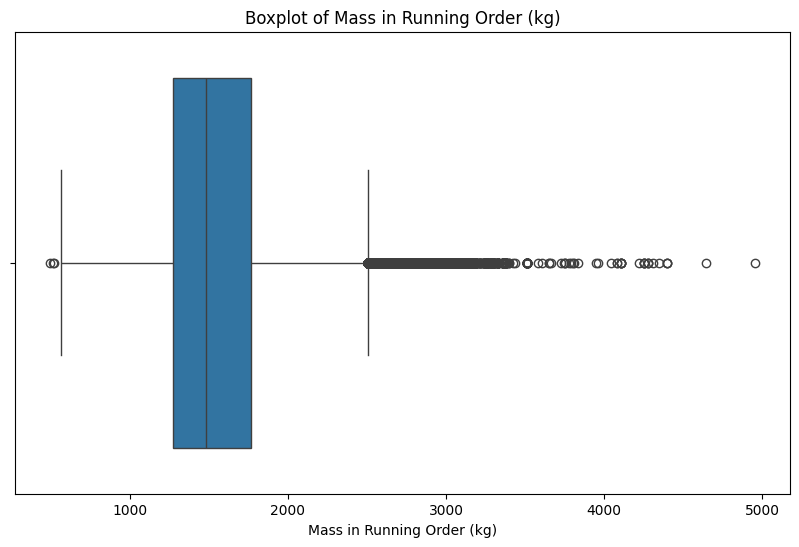

In [16]:
display(df_a['Mass_in_Running_Order(kg)'].head(20).mean())
# Checking for outliers in 'Mass_in_Running_Order(kg)' using IQR method
Q1 = df_a['Mass_in_Running_Order(kg)'].quantile(0.25)
Q3 = df_a['Mass_in_Running_Order(kg)'].quantile(0.75)
IQR = Q3 - Q1
outliers = df_a[(df_a['Mass_in_Running_Order(kg)'] < (Q1 - 1.5 * IQR)) | (df_a['Mass_in_Running_Order(kg)'] > (Q3 + 1.5 * IQR))]
print(f"Number of outliers in 'Mass_in_Running_Order(kg)': {len(outliers)}")
# Visualizing the distribution of 'Mass_in_Running_Order(kg)'
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_a['Mass_in_Running_Order(kg)'])
plt.title('Boxplot of Mass in Running Order (kg)')
plt.xlabel('Mass in Running Order (kg)')    

Number of outliers in 'WLTP_test_mass': 166119


Text(0.5, 1.0, 'Boxplot of WLTP Test Mass')

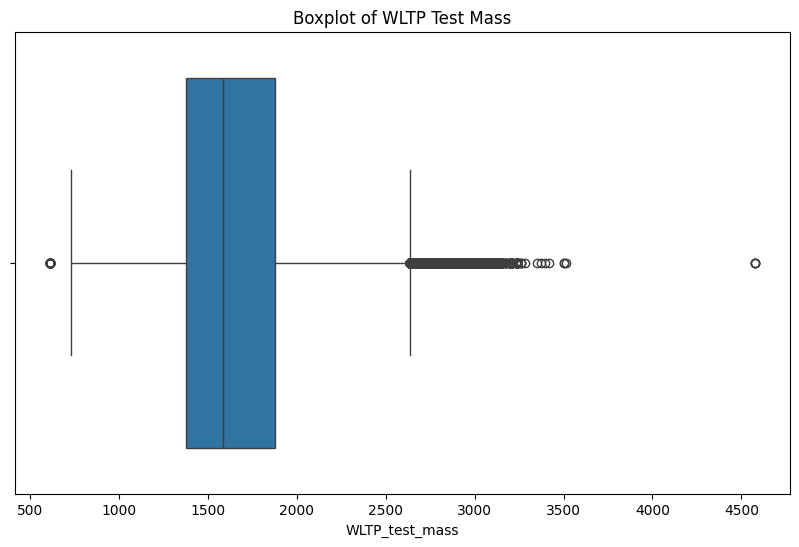

In [17]:
df_a['WLTP_test_mass'].describe()
# Checking for outliers in 'WLTP_test_mass' using IQR method
Q1_wltp = df_a['WLTP_test_mass'].quantile(0.25)
Q3_wltp = df_a['WLTP_test_mass'].quantile(0.75)
IQR_wltp = Q3_wltp - Q1_wltp
outliers_wltp = df_a[(df_a['WLTP_test_mass'] < (Q1_wltp - 1.5 * IQR_wltp)) | (df_a['WLTP_test_mass'] > (Q3_wltp + 1.5 * IQR_wltp))]
print(f"Number of outliers in 'WLTP_test_mass': {len(outliers_wltp)}") 
# Visualizing the distribution of 'WLTP_test_mass'
plt.figure(figsize=(10, 6))
sns.boxplot(x=df_a['WLTP_test_mass'])
plt.title('Boxplot of WLTP Test Mass')              

In [18]:
categorical_columns = df_a.select_dtypes(include=['object']).columns
print(f"Categorical columns found: {list(categorical_columns)}")

for col in categorical_columns:
    unique_count = df_a[col].nunique()
    print(f"\n{col}:")
    print(f"  - Unique values: {unique_count}")
    
    # Get value counts and percentages
    value_counts = df_a[col].value_counts()
    percentages = df_a[col].value_counts(normalize=True) * 100
    
    if unique_count <= 10:
        print(f"  - All values with distribution:")
        display_data = list(zip(value_counts.index, value_counts.values, percentages.values))
    else:
        print(f"  - Top 10 values with distribution:")
        display_data = list(zip(value_counts.head(10).index, value_counts.head(10).values, percentages.head(10).values))
    
    for val, count, pct in display_data:
        print(f"    {val}: {count} ({pct:.1f}%)")

Categorical columns found: ['Country', 'Vehicle_Family_id_number', 'Manufacturer_Pooling', 'Manufacturer_Name', 'Manufacturer_name_OEM', 'Type_approval_number', 'Type', 'Variant', 'Version', 'Make', 'Commercial_Name', 'Category_type_approved', 'Category_type_registered', 'Fuel_Type', 'Fuel_Mode', 'Innovative_Technologies', 'Status', 'Electric_Charge', 'RLFI']

Country:
  - Unique values: 29
  - Top 10 values with distribution:
    DE: 2765140 (25.8%)
    FR: 1889599 (17.6%)
    IT: 1564184 (14.6%)
    ES: 974231 (9.1%)
    BE: 477251 (4.4%)
    PL: 474735 (4.4%)
    NL: 364769 (3.4%)
    SE: 294548 (2.7%)
    AT: 238567 (2.2%)
    CZ: 217151 (2.0%)

Vehicle_Family_id_number:
  - Unique values: 8698
  - Top 10 values with distribution:
    IP-03_312_0344-ZFA-1: 191790 (1.9%)
    IP-0153-JT1-1: 118979 (1.2%)
    IP-0110-JT1-1: 94941 (0.9%)
    IP-JAA1MTPJT4A_000-VF1-1: 82075 (0.8%)
    IP-JFB1MTGJT4A_000-UU1-0: 69013 (0.7%)
    IP-HMH____MA5_5312-VR3-0: 62616 (0.6%)
    IP-HMR____MA5_131

### General Overview of Categorical Variables


- The most of the variable should be interpreted properly. We don't know how to interpret the values in the following categorical variables: 
    - Vehicle_Family_id_number
    - Type_approval_number
    - Type
    - Variant
    - Version
    - Category_type_approved
    - Fuel_Mode
    - Innovative_Technologies
    - Electric_Charge
    - RLFI



## TARGET VARIABLE ANALYSIS: CO2 (g/km)

In [19]:
### TARGET VARIABLE ANALYSIS: CO2 (g/km)

display(df_a['CO2_Emissions_WLTP(g/km)'].describe())

count   10713765.0
mean         106.7
std           59.6
min            0.0
25%          101.0
50%          123.0
75%          139.0
max          543.0
Name: CO2_Emissions_WLTP(g/km), dtype: float64

/var/folders/1l/gc0hh39x75x_yq00kr3g48zc0000gn/T/ipykernel_90889/1892595897.py:31: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/envs/dsCO2emission/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


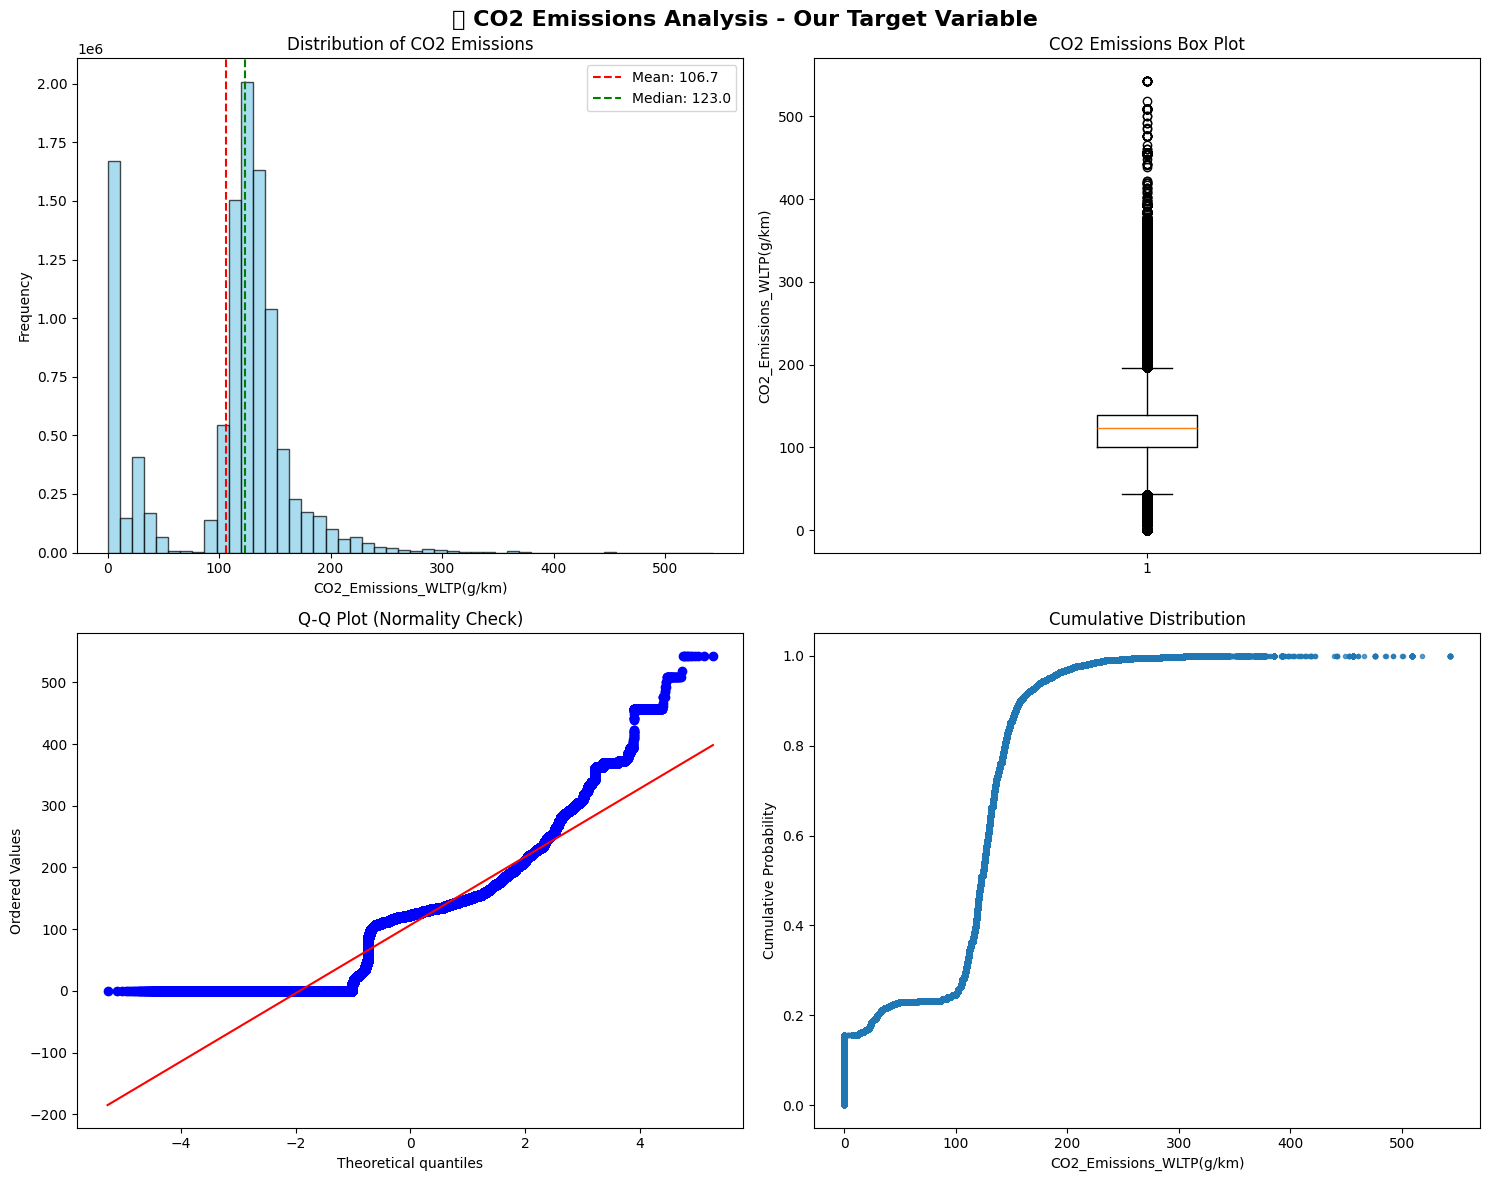

In [20]:
# Create comprehensive CO2 analysis plot
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('🎯 CO2 Emissions Analysis - Our Target Variable', fontsize=16, fontweight='bold')

# Distribution histogram
axes[0,0].hist(df_a['CO2_Emissions_WLTP(g/km)'].dropna(), bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].axvline(df_a['CO2_Emissions_WLTP(g/km)'].mean(), color='red', linestyle='--', label=f'Mean: {df_a["CO2_Emissions_WLTP(g/km)"].mean():.1f}')
axes[0,0].axvline(df_a['CO2_Emissions_WLTP(g/km)'].median(), color='green', linestyle='--', label=f'Median: {df_a["CO2_Emissions_WLTP(g/km)"].median():.1f}')
axes[0,0].set_title('Distribution of CO2 Emissions')
axes[0,0].set_xlabel('CO2_Emissions_WLTP(g/km)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend()

# Box plot
axes[0,1].boxplot(df_a['CO2_Emissions_WLTP(g/km)'].dropna())
axes[0,1].set_title('CO2 Emissions Box Plot')
axes[0,1].set_ylabel('CO2_Emissions_WLTP(g/km)')

# Q-Q plot for normality
stats.probplot(df_a['CO2_Emissions_WLTP(g/km)'].dropna(), dist="norm", plot=axes[1,0])
axes[1,0].set_title('Q-Q Plot (Normality Check)')

# Cumulative distribution
sorted_co2 = np.sort(df_a['CO2_Emissions_WLTP(g/km)'].dropna())
y = np.arange(1, len(sorted_co2) + 1) / len(sorted_co2)
axes[1,1].plot(sorted_co2, y, marker='.', linestyle='none', alpha=0.7)
axes[1,1].set_title('Cumulative Distribution')
axes[1,1].set_xlabel('CO2_Emissions_WLTP(g/km)')
axes[1,1].set_ylabel('Cumulative Probability')

plt.tight_layout()
plt.show()


The 0 and close to 0 CO2 emission values are most probably the electric cars. They should be investigated properly to understand what is the feature that distinguish them

In [22]:
# Displaying the features of CO2 Emissions free rows
df_a_CO2free = df_a[df_a['CO2_Emissions_WLTP(g/km)'] == 0]

display(df_a_CO2free['Fuel_Type'].value_counts())
display(df_a_CO2free['Fuel_Mode'].value_counts())


Fuel_Type
electric    1669449
hydrogen        730
ELECTRIC          1
Name: count, dtype: int64

Fuel_Mode
E    1669450
M        729
B          1
Name: count, dtype: int64

In [25]:
# Displaying the rows that have less than 50 g/km CO2 emissions
low_50_co2 = df_a[(df_a['CO2_Emissions_WLTP(g/km)'] < 50) & (df_a['CO2_Emissions_WLTP(g/km)'] > 0)]
print(f"Number of vehicles with CO2 emissions less than 50 g/km but not O: {len(low_50_co2)}")
# Displaying the rows with CO2 emissions less than 50 g/km
display(low_50_co2.head(5))

display(low_50_co2['Fuel_Type'].value_counts())

Number of vehicles with CO2 emissions less than 50 g/km but not O: 783013


,Vehicle_ID,Country,Vehicle_Family_id_number,Manufacturer_Pooling,Manufacturer_Name,Manufacturer_name_OEM,Type_approval_number,Type,Variant,Version,Make,Commercial_Name,Category_type_approved,Category_type_registered,Total_new_registrations,Mass_in_Running_Order(kg),WLTP_test_mass,CO2_Emissions_WLTP(g/km),Fuel_Type,Fuel_Mode,Engine_Capacity(cm3),Engine_Power(kW),Electric_Energy_Consumption(Wh/km),Innovative_Technologies,Emmission_reduction_through_innovation_WLTP,Status,year,Date of registration,Fuel consumption,Electric_Charge,RLFI,Electric range (km)
8,130815562,DE,IP-041225-U5Y-1,KIA,KIA SLOVAKIA,KIA SLOVAKIA SRO,e4*2007/46*1299*18,CD,F5P61,D61LZ1,KIA,CEED,M1,M1,1,1614.0,1750.0,33.0,petrol/electric,P,1580.0,77.0,125.0,NaN,NaN,P,2023,2023-04-27,1.5,NaN,RL-041203-U5Y-1,55.0
42,130815596,DE,IP-2021_3403-W1K-1,MERCEDES-BENZ AG,MERCEDES-BENZ AG,MERCEDES-BENZ AG,e1*2007/46*1560*33,R1ES,U21IT1,CZAA050E,MERCEDES-BENZ,E 300 DE 4MATIC,M1,M1,1,2215.0,2382.0,38.0,diesel/electric,P,1950.0,143.0,165.0,NaN,NaN,P,2023,2023-08-04,1.5,NaN,RL-2017_0220-WDB-1,47.0
79,130815633,DE,IP-MQB37AZ_B1_1935-WVW-1,VOLKSWAGEN,VOLKSWAGEN,VOLKSWAGEN AG,e1*2001/116*0450*68,5N,ACDGEAX0,FD6FD6DD002N5T6NVR24BI1BSB0M10SO,VOLKSWAGEN VW,TIGUAN,M1,M1,1,1816.0,2035.0,36.0,petrol/electric,P,1395.0,110.0,175.0,NaN,NaN,P,2023,2023-07-26,1.6,NaN,RL-DQ400E6F_20_001-WVW-1,52.0
82,130815636,DE,IP-MQB37AZ_A1_1935-WVW-1,VOLKSWAGEN,VOLKSWAGEN,VOLKSWAGEN AG,e1*2001/116*0450*67,5N,ACDGEAX0,FD6FD6DD002N5T6NVR24BI1BSA0M10SO,VOLKSWAGEN VW,TIGUAN,M1,M1,1,1816.0,1985.0,35.0,petrol/electric,P,1395.0,110.0,173.0,NaN,NaN,P,2023,2023-03-01,1.5,NaN,RL-DQ400E6F_20_001-WVW-1,53.0
106,130815660,DE,IP-VN41TZZ_A4_0474-WVN-1,VOLKSWAGEN,VOLKSWAGEN,VOLKSWAGEN AG,e1*2018/858*00018*08,ST,MDGEAX0,MNFD6FD6DD00217T4BI1A700A,VOLKSWAGEN VW,MULTIVAN,M1,M1,1,2194.0,2382.0,42.0,petrol/electric,P,1395.0,110.0,173.0,NaN,NaN,P,2023,2023-10-11,1.9,NaN,RL-DQ400E6F_20_701-WVN-1,47.0


Fuel_Type
petrol/electric    757726
diesel/electric     25239
PETROL/ELECTRIC        28
petrol                 19
diesel                  1
Name: count, dtype: int64

As the extreme values are legit, we cannot remove them from the dataset

## **Correlation between variables**

### Correlation matrix

Correlation with CO2 emissions:
CO2_Emissions_WLTP(g/km)                       1.0
Fuel consumption                               1.0
Engine_Capacity(cm3)                           0.3
Electric_Energy_Consumption(Wh/km)             0.2
Emmission_reduction_through_innovation_WLTP    0.0
Engine_Power(kW)                              -0.1
WLTP_test_mass                                -0.2
Mass_in_Running_Order(kg)                     -0.3
Electric range (km)                           -0.8
Name: CO2_Emissions_WLTP(g/km), dtype: float64


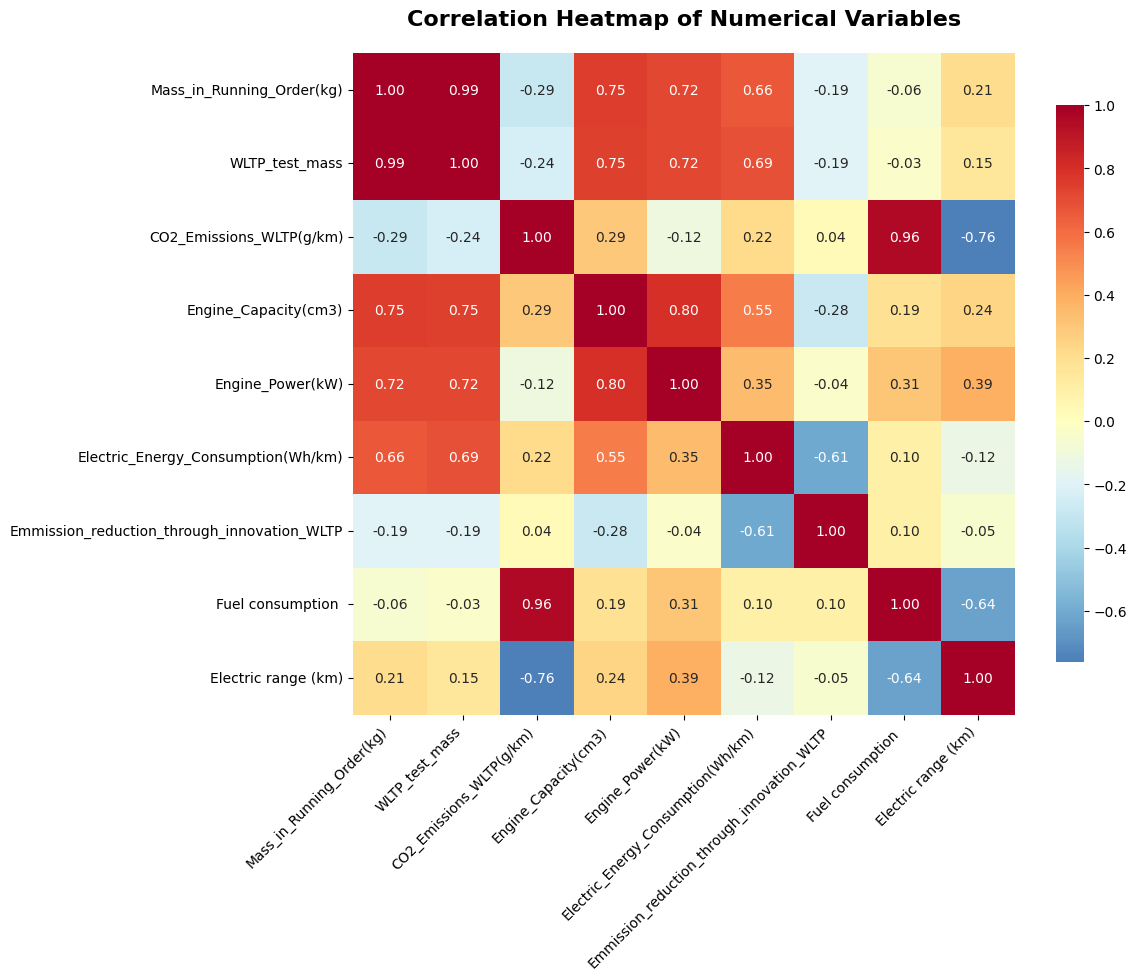

In [28]:
# Correlation analysis with CO2 emissions
# Selecting numerical columns for correlation analysis
numerical_cols = df_a.select_dtypes(include=[np.number]).columns
columns_to_exclude = ['Total_new_registrations', 'year', 'Vehicle_ID']
numerical_cols_filtered = numerical_cols.drop(columns_to_exclude)

#display(numerical_cols)
corr_with_co2 = df_a[numerical_cols_filtered].corr()['CO2_Emissions_WLTP(g/km)'].sort_values(ascending=False)
print("Correlation with CO2 emissions:")
print(corr_with_co2)

# Create correlation matrix for all numerical columns
correlation_matrix = df_a[numerical_cols_filtered].corr()

# Create the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, 
            annot=True,           # Show correlation values
            cmap='RdYlBu_r',      # Color scheme (red-yellow-blue reversed)
            center=0,             # Center colormap at 0
            square=True,          # Make cells square-shaped
            fmt='.2f',            # Format numbers to 2 decimal places
            cbar_kws={'shrink': 0.8})  # Adjust colorbar size

plt.title('Correlation Heatmap of Numerical Variables', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Correlation with CO2 emissions:
CO2_Emissions_WLTP(g/km)                       1.0
Fuel consumption                               1.0
Engine_Capacity(cm3)                           0.3
Electric_Energy_Consumption(Wh/km)             0.2
Vehicle_ID                                     0.2
Emmission_reduction_through_innovation_WLTP    0.0
Engine_Power(kW)                              -0.1
WLTP_test_mass                                -0.2
Mass_in_Running_Order(kg)                     -0.3
Electric range (km)                           -0.8
Total_new_registrations                        NaN
year                                           NaN
Name: CO2_Emissions_WLTP(g/km), dtype: float64


/var/folders/1l/gc0hh39x75x_yq00kr3g48zc0000gn/T/ipykernel_90889/1279413705.py:51: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/envs/dsCO2emission/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


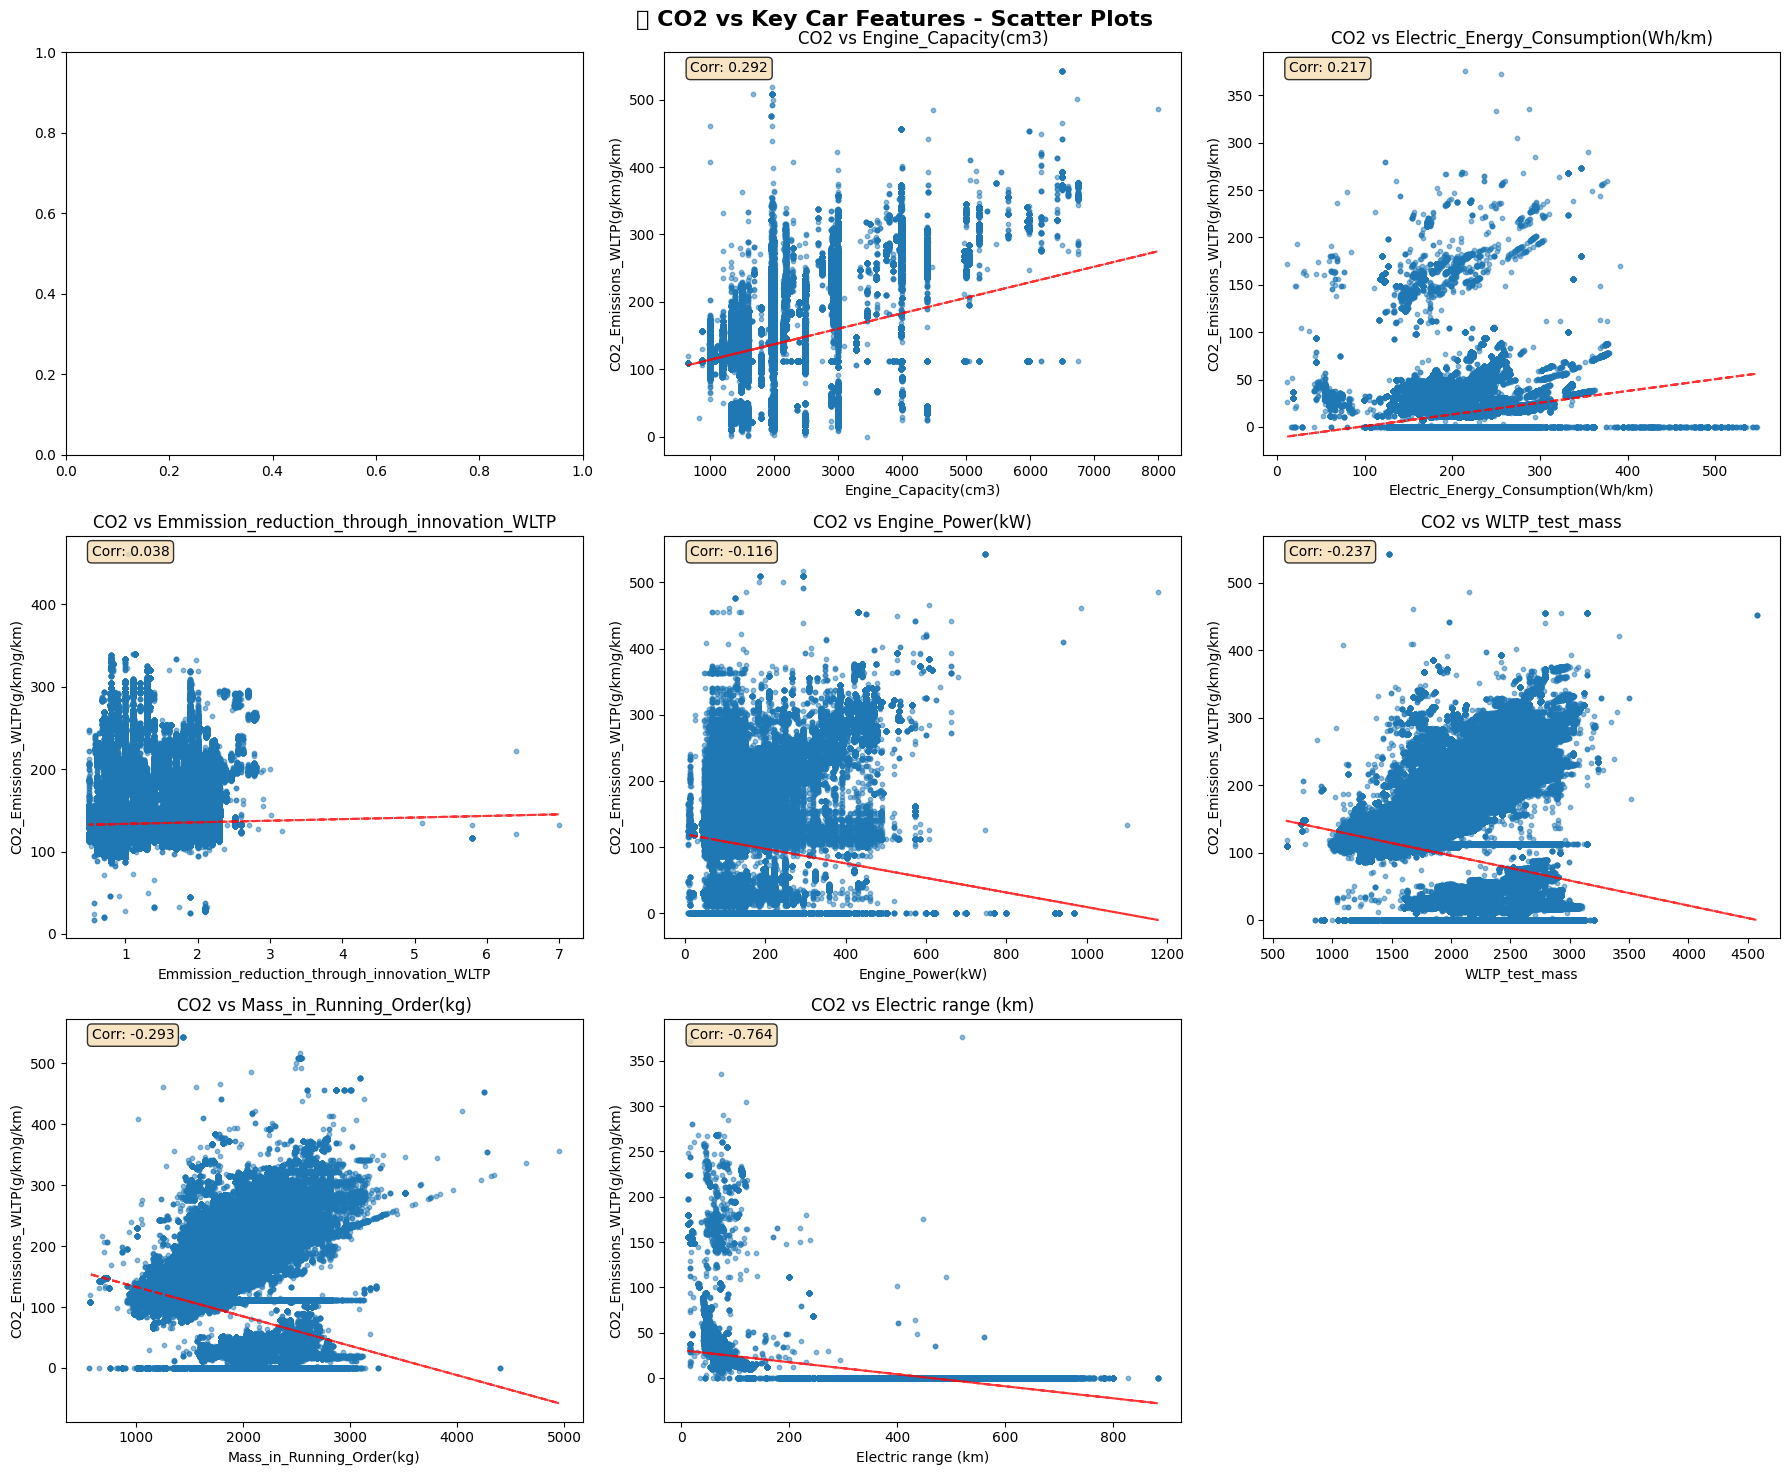

In [31]:
# KEY RELATIONSHIPS: CO2 vs NUMERICAL FEATURES

key_numerical = ['Fuel_Consumption',
                 'Engine_Capacity(cm3)',
                 'Electric_Energy_Consumption(Wh/km)',
                 'Emmission_reduction_through_innovation_WLTP',
                 'Engine_Power(kW)',
                 'WLTP_test_mass',
                 'Mass_in_Running_Order(kg)',
                 'Electric range (km)']


numerical_cols = df_a.select_dtypes(include=[np.number]).columns
corr_with_co2 = df_a[numerical_cols].corr()['CO2_Emissions_WLTP(g/km)'].sort_values(ascending=False)
print("Correlation with CO2 emissions:")
print(corr_with_co2)

import math

# Scatter plots for key relationships
n_features = len(key_numerical)
n_cols = 3
n_rows = math.ceil(n_features / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
fig.suptitle('🔍 CO2 vs Key Car Features - Scatter Plots', fontsize=16, fontweight='bold')

# Flatten axes for easy indexing
axes = axes.flatten() if n_features > 1 else [axes]

for i, feature in enumerate(key_numerical):
    if feature in df_a.columns:
        clean_data = df_a[[feature, 'CO2_Emissions_WLTP(g/km)']].dropna()
        axes[i].scatter(clean_data[feature], clean_data['CO2_Emissions_WLTP(g/km)'], alpha=0.5, s=10)
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('CO2_Emissions_WLTP(g/km)g/km)')
        axes[i].set_title(f'CO2 vs {feature}')
        # Add trend line
        if len(clean_data) > 1:
            z = np.polyfit(clean_data[feature], clean_data['CO2_Emissions_WLTP(g/km)'], 1)
            p = np.poly1d(z)
            axes[i].plot(clean_data[feature], p(clean_data[feature]), "r--", alpha=0.8)
        # Add correlation coefficient
        corr = clean_data[feature].corr(clean_data['CO2_Emissions_WLTP(g/km)'])
        axes[i].text(0.05, 0.95, f'Corr: {corr:.3f}', transform=axes[i].transAxes, 
                     bbox=dict(boxstyle="round", facecolor='wheat', alpha=0.8))

# Remove unused subplots
for j in range(i + 1, n_rows * n_cols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


### Multicolinearity
There are some variables that show Multicolinearity, we could look for them with a variance inflation factor

In [182]:
from statsmodels.stats.outliers_influence import variance_inflation_factor


In [183]:
# VIF calculation
vif = pd.DataFrame()
vif["Variable"] = df_num.columns
vif["VIF"] = [variance_inflation_factor(df_num.values, i) for i in range(df_num.shape[1])]

print(vif)

                            Variable           VIF
0                       Fiscal_Power  2.247420e+04
1                      Max_Power(kW)  1.751192e+04
2         Urban_Consumption(L/100km)  3.173689e+06
3   Extra-urban_Consumption(L/100km)  2.149112e+06
4      Combined_Consumption(L/100km)  1.079079e+07
5                          CO2(g/km)  2.347924e+04
6                    CO_Type_I(g/km)  9.487487e+01
7                           HC(g/km)  5.946665e+03
8                          NOX(g/km)  1.609529e+03
9                       HC+NOX(g/km)  6.921638e+02
10                   Particles(g/km)  5.913185e+01
11              Unladen_Mass_Min(kg)  2.521753e+04
12              Unladen_Mass_Max(kg)  2.848056e+04


With this we can conclude adjustment for the next variables
1. Urban, Extra-urban, and Combined Consumption are high correlated <br>
 with CO2
Suggestion: In the future for the analysis with the EEA Data base, <br> 
maybe would be ok if we just keep CO2 Consumption
2. Max_Power vs Fiscal_Power are almost the same
Suggestion: Keep only one (e.g., Max_Power(kW)<br>
 is more physically 
 meaningful)
3. Unladen Mass Min vs Max: Close to be redundant
Suggestion: Keep max
4. Pollutant Gases (NOX, HC, Particles, HC+NOX)
Sggestion: in the future if we concentrate in CO2 pollution, <br>
we could drop them



After studying the correlation, we might think the following numerical variables for the model

- Max_Power(kW)
- Unladen_Mass_Max(kg)
- NOX(g/km), HC+NOX(g/km) (should be investigated further before the final decision)


Potential Categorical Variable that could be used in the model

- Fuel_Type
- Hybrid
- Gearbox
- Body_Type
- Segment


In [236]:
df.columns

Index(['Brand', 'Project_Model', 'UTAC_Model', 'Commercial_Name', 'CNIT',
       'TVV', 'Fuel_Type', 'Hybrid', 'Fiscal_Power', 'Max_Power(kW)',
       'Gearbox', 'Urban_Consumption(L/100km)',
       'Extra-urban_Consumption(L/100km)', 'Combined_Consumption(L/100km)',
       'CO2(g/km)', 'CO_Type_I(g/km)', 'HC(g/km)', 'NOX(g/km)', 'HC+NOX(g/km)',
       'Particles(g/km)', 'Unladen_Mass_Min(kg)', 'Unladen_Mass_Max(kg)',
       'Field_V9', 'Update_Date', 'Body_Type', 'Segment'],
      dtype='object')

### Correlation of Variables

#### Does Fuel Type has a relationship with CO2 Emmissions

In order to see if the Maximal Mass has an influence in the CO2, we should <br>
differentiate those cars that use Gasoline/Diesel and the electric ones. Lets <br>
make first an exploration of how is the data of fuel type

In [188]:
df['Fuel_Type'].value_counts(normalize=True)

Fuel_Type
GO       0.842319
ES       0.137280
EH       0.004437
ES/GN    0.003924
GN/ES    0.003924
ES/GP    0.002230
GP/ES    0.002230
GN       0.001315
GH       0.001204
EL       0.000870
FE       0.000178
EE       0.000067
GL       0.000022
Name: proportion, dtype: float64

The first 3 Categories (GO, ES and EH) are already the 97% <br>
of the cars total. <br>
85% of the cars are driven with gasoline <br>
and 13% are diesel, below the 1% is hybrid

In [189]:
df['Fuel_Type'].value_counts(normalize=True).keys()[0:3]



Index(['GO', 'ES', 'EH'], dtype='object', name='Fuel_Type')

On the internet we could figure out, what GO, ES and EH mean

In [190]:
labels = {"GO": "Gasoline", "ES":"Diesel", "EH": "hybrid"}

/var/folders/1l/gc0hh39x75x_yq00kr3g48zc0000gn/T/ipykernel_70312/1218593849.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  fig.set_xticklabels(['Gasoline','Diesel','Hybrid'])


Text(0.5, 1.0, 'CO₂ Emissions by Fuel Type')

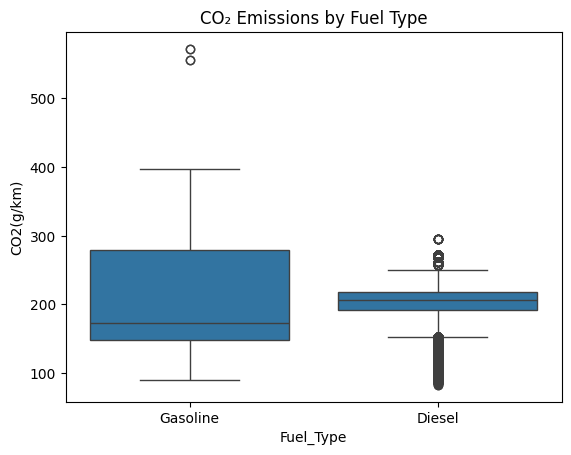

In [191]:
df_filter = df[(df['Fuel_Type'] == 'ES') | (df['Fuel_Type'] == 'GO')]

fig = sns.boxplot(x=df_filter['Fuel_Type'], y=df_filter['CO2(g/km)'])

fig.set_xticklabels(['Gasoline','Diesel','Hybrid'])

plt.title('CO₂ Emissions by Fuel Type')


The mean between gasoline and diesel has a difference, is this <br>
a significant difference? <br>

let's apply Welch's t-test in order to respond this question:<br>
<br>
    - H0: There is no significant difference in the CO2 Consumption<br>
    levels between Gasoline and Diesel.<br>
    <br>
    - H1: There is a significant difference in the CO2 Consumption <br>
    levels between Gasoline and Diesel.<br>
        

In [192]:
from scipy.stats import ttest_ind

# Filter CO₂ data for each fuel type
es_co2 = df_filter[df_filter['Fuel_Type'] == 'ES']['CO2(g/km)']
go_co2 = df_filter[df_filter['Fuel_Type'] == 'GO']['CO2(g/km)']

# Apply Welch's t-test (does not assume equal variances)
t_stat, p_value = ttest_ind(es_co2, go_co2, equal_var=False)

print("T-statistic:", t_stat)
print("p-value:", p_value)

if p_value>0.05:
    print("p_value>0.05 Fail to reject the null (not significant difference)")
else:
    print("p_value<0.05 Reject the null hypothesis (significant difference)")

T-statistic: 0.3724281026518655
p-value: 0.7095860630521096
p_value>0.05 Fail to reject the null (not significant difference)


#### Does Maximal mass has a relationship with CO2 Emmissions

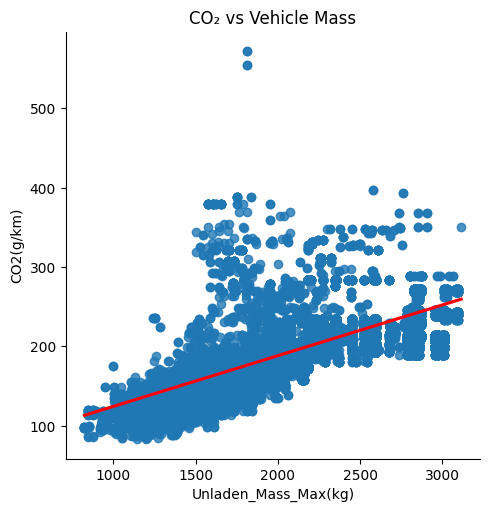

In [193]:
sns.lmplot(x='Unladen_Mass_Max(kg)', y='CO2(g/km)',
           line_kws={'color': 'red'},
           data= df_filter)
plt.title('CO₂ vs Vehicle Mass')
plt.show()

it seems to be a relationship between Mass and CO2 <br>

let's make "Pearson's r" test perform to see if there is a linear <br>
correlation

In [194]:
# Example: mass vs CO2
from scipy.stats import pearsonr
r, p = pearsonr(df_filter['Unladen_Mass_Max(kg)'], df_filter['CO2(g/km)'])

print("Correlation coefficient (r):", r)
print("p-value:", p)


Correlation coefficient (r): 0.6724436516215779
p-value: 0.0


The r value is high so there is strong positive correlation <br>
and the p-value: < 0.05, so it is significant the relationship <br>
so: Does Maximal mass has a relationship with CO2 Emissions?<br>
YES it has a strong positive relationship

#### Does the gear box type has a relationship with CO2 Emmisions?

In [195]:
df_filter['Gearbox'].value_counts(normalize=True)

Gearbox
M 6    0.438671
A 5    0.308797
A 7    0.188506
M 5    0.025265
A 6    0.024878
A 8    0.009764
V 0    0.001343
D 5    0.000888
A 4    0.000865
D 7    0.000478
M 7    0.000273
D 6    0.000250
S 6    0.000023
Name: proportion, dtype: float64

In [196]:
df_filter

,Brand,Project_Model,UTAC_Model,Commercial_Name,CNIT,TVV,Fuel_Type,Hybrid,Fiscal_Power,Max_Power(kW),...,HC(g/km),NOX(g/km),HC+NOX(g/km),Particles(g/km),Unladen_Mass_Min(kg),Unladen_Mass_Max(kg),Field_V9,Update_Date,Body_Type,Segment
0,ALFA-ROMEO,159,159,159 1750 Tbi (200ch),M10ALFVP000G340,939AXN1B52C,ES,non,12.0,147.0,...,0.052,0.032,NaN,0.002,1505.0,1505.0,715/2007*692/2008EURO5,juin-13,BREAK,MOY-SUPER
1,ALFA-ROMEO,159,159,159 2.0 JTDm (170ch) ECO,M10ALFVP000U221,939AXP1B54C,GO,non,9.0,125.0,...,NaN,0.169,0.190,0.003,1565.0,1565.0,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER
2,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),M10ALFVP000E302,939AXR1B64,GO,non,7.0,100.0,...,NaN,0.149,0.175,0.001,1565.0,1565.0,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER
3,ALFA-ROMEO,159,159,159 2.0 JTDm (136ch),M10ALFVP000F303,939AXR1B64B,GO,non,7.0,100.0,...,NaN,0.149,0.175,0.001,1565.0,1565.0,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER
4,ALFA-ROMEO,159,159,159 2.0 JTDm (170ch),M10ALFVP000G304,939AXS1B66,GO,non,9.0,125.0,...,NaN,0.164,0.193,0.001,1565.0,1565.0,715/2007*692/2008EURO5,juin-13,BERLINE,MOY-SUPER
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44845,VOLVO,XC70,XC70,XC70 D4 (163ch) AWD Geartronic 6,M10VLVVP874P723,BZ8756,GO,non,10.0,120.0,...,NaN,0.116,0.152,0.000,1799.0,1799.0,715/2007*630/2012EURO5,juin-13,BREAK,SUPERIEURE
44846,VOLVO,XC70,XC70,XC70 D4 (163ch) Stop&Start AWD BVM6,M10VLVVP8725584,BZ87A4,GO,non,9.0,120.0,...,NaN,0.106,0.144,0.000,1786.0,1786.0,715/2007*630/2012EURO5,juin-13,BREAK,SUPERIEURE
44847,VOLVO,XC70,XC70,XC70 D4 (163ch) Geartronic 6,M10VLVVP8726585,BZ8850,GO,non,9.0,120.0,...,NaN,0.108,0.132,0.001,1726.0,1726.0,715/2007*630/2012EURO5,juin-13,BREAK,SUPERIEURE
44848,VOLVO,XC70,XC70,XC70 D4 (163ch) Stop&Start BVM6,M10VLVVP8727586,BZ88A1,GO,non,9.0,120.0,...,NaN,0.127,0.152,0.001,1706.0,1706.0,715/2007*630/2012EURO5,juin-13,BREAK,SUPERIEURE


In [197]:
main_gb = ['M 6','A 5','A 7'] #90% of the data falls into these three categories

df_filter_mgb = df_filter[df_filter['Gearbox'].isin(main_gb)]


In [198]:
df_filter_mgb['Gearbox'].value_counts(normalize=True)

Gearbox
M 6    0.468679
A 5    0.329921
A 7    0.201401
Name: proportion, dtype: float64

/var/folders/1l/gc0hh39x75x_yq00kr3g48zc0000gn/T/ipykernel_70312/298571972.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  fig.set_xticklabels(['Manual 6 ','Autom. 5','Autom. 7'])


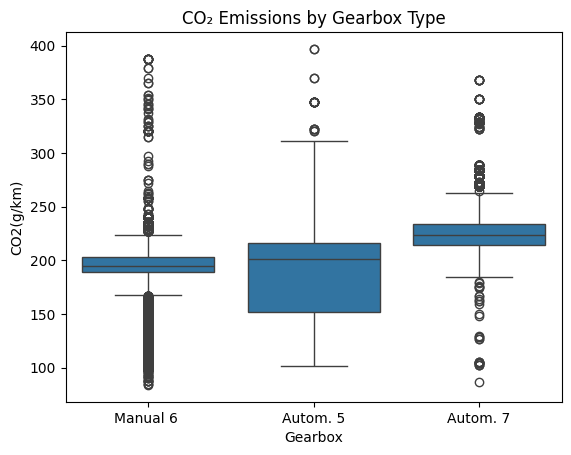

In [199]:

fig = sns.boxplot(x=df_filter_mgb['Gearbox'], y=df_filter_mgb['CO2(g/km)'])

fig.set_xticklabels(['Manual 6 ','Autom. 5','Autom. 7'])
plt.title('CO₂ Emissions by Gearbox Type')

plt.show()


Between Manual and automatic 5 (5 gears) there is a slightly <br>
difference in the mean. The automatic 7 has a higher mean than the<br>
other two. But is it this difference due to the gearbox type <br>
or because this 'gearbox' type are mainly to see in "sport" cars <br>
or  in cars bigger than standard cars? <br>. In those cases the <br> 
cylinders are bigger and therefore more CO2 consumption?


In [200]:
df_filter_mgb[df_filter_mgb['Gearbox'] == 'A 7']['Body_Type'].value_counts(normalize=True)

Body_Type
MINIBUS                0.412340
BERLINE                0.243057
BREAK                  0.143927
COUPE                  0.064598
TS TERRAINS/CHEMINS    0.062545
CABRIOLET              0.033084
MONOSPACE COMPACT      0.028013
COMBISPACE             0.012437
Name: proportion, dtype: float64

We don't see really a pattern

#### Does the segment has a relationship with CO2 Consumption?

In [201]:
df_filter['Segment'].value_counts(normalize=True)

Segment
MOY-INFER     0.458382
MOY-SUPER     0.344008
LUXE          0.114100
SUPERIEURE    0.044338
INFERIEURE    0.034915
ECONOMIQUE    0.004211
MOY-INF       0.000046
Name: proportion, dtype: float64

In [202]:
main_seg = df_filter["Segment"].value_counts().index[:4]

main_seg

Index(['MOY-INFER', 'MOY-SUPER', 'LUXE', 'SUPERIEURE'], dtype='object', name='Segment')

In [203]:
df_filter_seg = df[df["Segment"].isin(main_seg)]

/var/folders/1l/gc0hh39x75x_yq00kr3g48zc0000gn/T/ipykernel_70312/627092353.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  fig.set_xticklabels(['Lower-Mid Segment', 'Upper-Mid Segment ', 'Luxury', 'Upper Segment'])


[Text(0, 0, 'Lower-Mid Segment'),
 Text(1, 0, 'Upper-Mid Segment '),
 Text(2, 0, 'Luxury'),
 Text(3, 0, 'Upper Segment')]

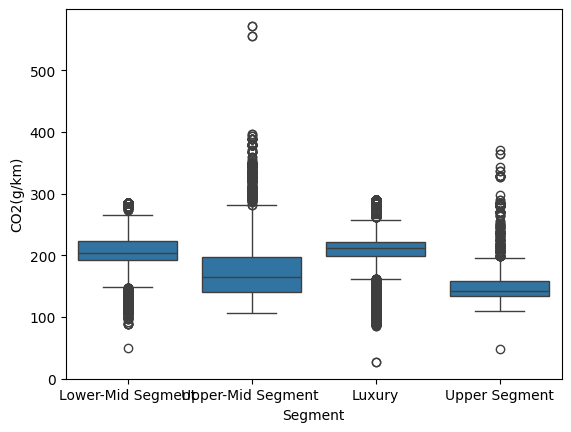

In [204]:

fig = sns.boxplot(x=df_filter_seg['Segment'], y=df_filter_seg['CO2(g/km)'])

fig.set_xticklabels(['Lower-Mid Segment', 'Upper-Mid Segment ', 'Luxury', 'Upper Segment'])



#### Does Max Power has a relationship with CO2 Consumption?

In [205]:
df_filter['Body_Type'].value_counts(normalize=True)

Body_Type
MINIBUS                0.740731
BERLINE                0.103539
BREAK                  0.051303
TS TERRAINS/CHEMINS    0.027518
COUPE                  0.024969
COMBISPACE             0.019051
CABRIOLET              0.013725
MONOSPACE COMPACT      0.013429
MINISPACE              0.003141
MONOSPACE              0.002595
Name: proportion, dtype: float64

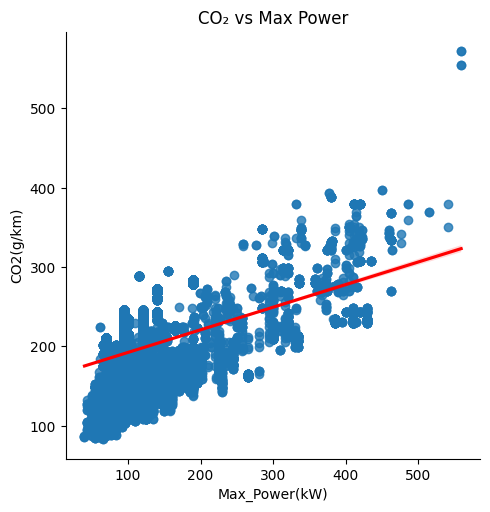

In [206]:
sns.lmplot(x='Max_Power(kW)', y='CO2(g/km)',
            line_kws={'color': 'red'},
           data= df_filter)
plt.title('CO₂ vs Max Power')
plt.show()

The Max Power seems to be strongly related with CO2 emmsion, this <br>
makes sense because 
is also other hypothesis we have to explore

In [207]:
# Mass vs CO2
r, p = pearsonr(df_filter['Max_Power(kW)'], df_filter['CO2(g/km)'])

print("Correlation coefficient (r):", r)
print("p-value:", p)

Correlation coefficient (r): 0.3646880782020383
p-value: 0.0


it has a moderate relationship, not strong as <br>
mass though.<br>
This makes sense mechanically too — heavier cars naturally <br>
require more fuel, regardless of how powerful the engine is.

#### Does Body Type has a relationship with CO2 Consumption?

In [208]:
main_bt = df_filter['Body_Type'].value_counts(normalize=True).index[:5]
main_bt

Index(['MINIBUS', 'BERLINE', 'BREAK', 'TS TERRAINS/CHEMINS', 'COUPE'], dtype='object', name='Body_Type')

In [209]:
#filter main body types (for visualisation)
df_filter_bt = df_filter[df_filter['Body_Type'].isin(main_bt)]

In [210]:
df_filter_bt['Body_Type'].value_counts()

Body_Type
MINIBUS                32544
BERLINE                 4549
BREAK                   2254
TS TERRAINS/CHEMINS     1209
COUPE                   1097
Name: count, dtype: int64

In [211]:
df_filter_seg['Body_Type'].isnull().sum()


np.int64(0)

/var/folders/1l/gc0hh39x75x_yq00kr3g48zc0000gn/T/ipykernel_70312/2922057836.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  fig.set_xticklabels(["Station Wagon", 'Sedan ', 'Convertible', 'Coupe', "SUV", "MPV", "Minivan_Comp.","Minibus","Ut_Van"])


[Text(0, 0, 'Station Wagon'),
 Text(1, 0, 'Sedan '),
 Text(2, 0, 'Convertible'),
 Text(3, 0, 'Coupe'),
 Text(4, 0, 'SUV'),
 Text(5, 0, 'MPV'),
 Text(6, 0, 'Minivan_Comp.'),
 Text(7, 0, 'Minibus'),
 Text(8, 0, 'Ut_Van')]

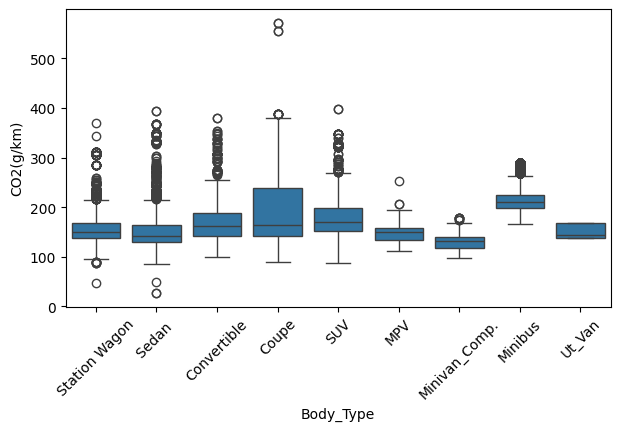

In [212]:

fig = sns.boxplot(x=df_filter_seg['Body_Type'], y=df_filter_seg['CO2(g/km)'])

plt.xticks(rotation=45)

plt.tight_layout()



fig.set_xticklabels(["Station Wagon", 'Sedan ', 'Convertible', 'Coupe', "SUV", "MPV", "Minivan_Comp.","Minibus","Ut_Van"])


In [213]:
from scipy.stats import f_oneway

groups = [
    group['CO2(g/km)'].dropna()
    for name, group in df_filter.groupby('Body_Type')
]

# Perform ANOVA
f_stat, p_value = f_oneway(*groups)

print("F-statistic:", f_stat)
print("p-value:", p_value)

F-statistic: 3832.5821432623975
p-value: 0.0


In [214]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=df_filter['CO2(g/km)'], groups=df_filter['Body_Type'], alpha=0.05)
print(tukey)

             Multiple Comparison of Means - Tukey HSD, FWER=0.05              
      group1             group2       meandiff p-adj   lower    upper   reject
------------------------------------------------------------------------------
          BERLINE               BREAK  10.9492    0.0   8.6232  13.2753   True
          BERLINE           CABRIOLET  24.5952    0.0  20.6817  28.5088   True
          BERLINE          COMBISPACE   1.8308 0.7927  -1.5655   5.2272  False
          BERLINE               COUPE  47.4919    0.0  44.4544  50.5293   True
          BERLINE             MINIBUS  64.4797    0.0  63.0503  65.9091   True
          BERLINE           MINISPACE -19.9233    0.0 -27.7261 -12.1205   True
          BERLINE           MONOSPACE   0.4001    1.0  -8.1628   8.9631  False
          BERLINE   MONOSPACE COMPACT -18.6075    0.0  -22.559 -14.6561   True
          BERLINE TS TERRAINS/CHEMINS  31.6993    0.0  28.7774  34.6212   True
            BREAK           CABRIOLET   13.646    0.

In [215]:
df_filter['Body_Type'].isnull().sum()

np.int64(0)

In [216]:
df_filter['CO2(g/km)'].isnull().sum()

np.int64(0)